In [258]:
import torch
import anemoi.graphs
import torch_geometric
from anemoi.graphs.create import GraphCreator
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [259]:
cfgs = [
    "/Users/michelecattaneo/Documents/SDSC/S-RUC/graph_imprinting/graph_configs/standard_hidden.yaml"
]

In [260]:
cfg = cfgs[-1]
gc = GraphCreator(OmegaConf.load(cfg))

In [261]:
out_graph_pth = f'../graphs/{cfg.split("/")[-1].split(".")[0]}.pt'
gc.create(save_path=out_graph_pth, overwrite=True)

HeteroData(
  hidden={
    x=[10242, 2],
    node_type='TriNodes',
  },
  (hidden, to, hidden)={
    edge_index=[2, 81840],
    edge_type='MultiScaleEdges',
  }
)

In [262]:
graph = torch.load(out_graph_pth, map_location='cpu', weights_only=False)

In [263]:
nodes = graph['hidden'].x

In [264]:
import numpy as np


# 3D Cartesian coordinates for all nodes from the 2d latlon
cartesian_pos = {}
for n, data in enumerate(nodes):
    lat, lon = data 
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    cartesian_pos[n] = (x, y, z)


/var/folders/2j/9d16145d2yb0z6741_qby2d00000gn/T/ipykernel_28493/3034994605.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x = np.cos(lat) * np.cos(lon)
/var/folders/2j/9d16145d2yb0z6741_qby2d00000gn/T/ipykernel_28493/3034994605.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = np.cos(lat) * np.sin(lon)
/var/folders/2j/9d16145d2yb0z6741_qby2d00000gn/T/ipykernel_28493/3034994605.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  z = np.sin(lat)


In [265]:
edges = graph['hidden', 'to', 'hidden'].edge_index.T
edge_index = graph['hidden', 'to', 'hidden'].edge_index

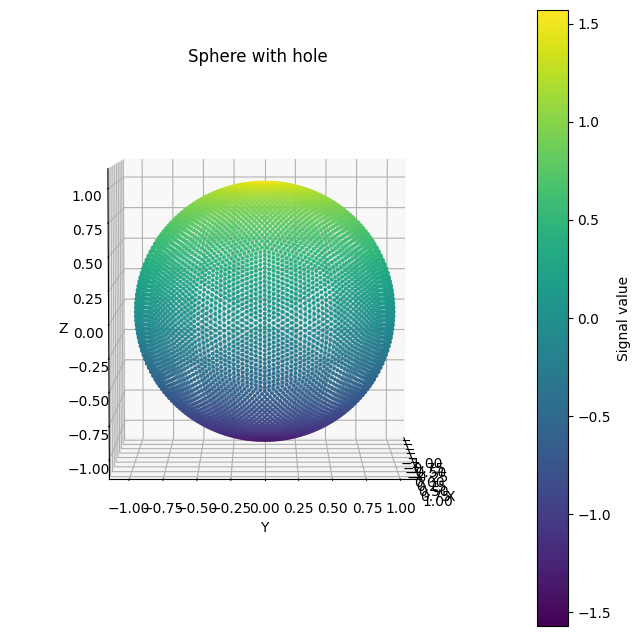

In [266]:

def draw_graph(cartesian_pos, signal, edges):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')

    # # draw edges
    # for u, v in edges:
        # v = v.item()
        # u = u.item()
        # # if mask_plot[u] and mask_plot[v]:
        # #     color = 'tomato'
        # # elif not mask_plot[u] and not mask_plot[v]:
        # #     color = 'royalblue'
        # # else: 
        # #     color = 'grey'
        # color='grey'

        # x_pair = [cartesian_pos[u][0], cartesian_pos[v][0]]
        # y_pair = [cartesian_pos[u][1], cartesian_pos[v][1]]
        # z_pair = [cartesian_pos[u][2], cartesian_pos[v][2]]
        # ax.plot(x_pair, y_pair, z_pair, color=color, alpha=0.9, linewidth=0.5)

    # draw nodes
    x_nodes = [c[0] for c in cartesian_pos.values()]
    y_nodes = [c[1] for c in cartesian_pos.values()]
    z_nodes = [c[2] for c in cartesian_pos.values()]
    sc = ax.scatter(x_nodes, y_nodes, z_nodes, c=signal, cmap='viridis', s=3)

    plt.colorbar(sc, ax=ax, label="Signal value")
    
    ax.set_box_aspect([1,1,1])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title("Sphere with hole")
    elev = 5 
    azim = 0
    ax.view_init(elev=elev, azim=azim)
    plt.show()


draw_graph(cartesian_pos=cartesian_pos, signal=nodes[:,0], edges=None)

In [435]:
gnn = torch_geometric.nn.conv.ChebConv(in_channels=2, out_channels=1, K=8, bias=True)
# gnn = torch_geometric.nn.models.GCN(in_channels=2, out_channels=1, num_layers=8, hidden_channels=2)

In [466]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, ModuleList, LayerNorm
from torch_geometric.nn import TransformerConv

class TransformerGNN(torch.nn.Module):
    def __init__(self,
                 in_channels=2,
                 hidden_channels=64,
                 out_channels=1,
                 num_layers=4,
                 heads=4):

        super().__init__()

        assert hidden_channels % heads == 0, \
            "hidden_channels must be divisible by heads"

        self.input_lin = Linear(in_channels, hidden_channels)

        self.convs = ModuleList([
            TransformerConv(
                hidden_channels,
                hidden_channels // heads,
                heads=heads,
                dropout=0.0
            )
            for _ in range(num_layers)
        ])

        self.norms = ModuleList([
            LayerNorm(hidden_channels)
            for _ in range(num_layers)
        ])

        self.output_lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):

        x = self.input_lin(x)
        x = F.relu(x)

        for conv, norm in zip(self.convs, self.norms):

            identity = x

            x = conv(x, edge_index)
            x = norm(x)

            x = F.relu(x)
            x = x + identity

            # x = F.dropout(x, p=0.1, training=self.training)

        return self.output_lin(x)

In [467]:
gnn = TransformerGNN(in_channels=2, hidden_channels=16, out_channels=1, num_layers=3, heads=4)

In [468]:
nodes.shape

torch.Size([10242, 2])

In [471]:
gnn = gnn.eval()
out = gnn(torch.randn_like(nodes), edge_index)
# out = gnn(nodes, edge_index)

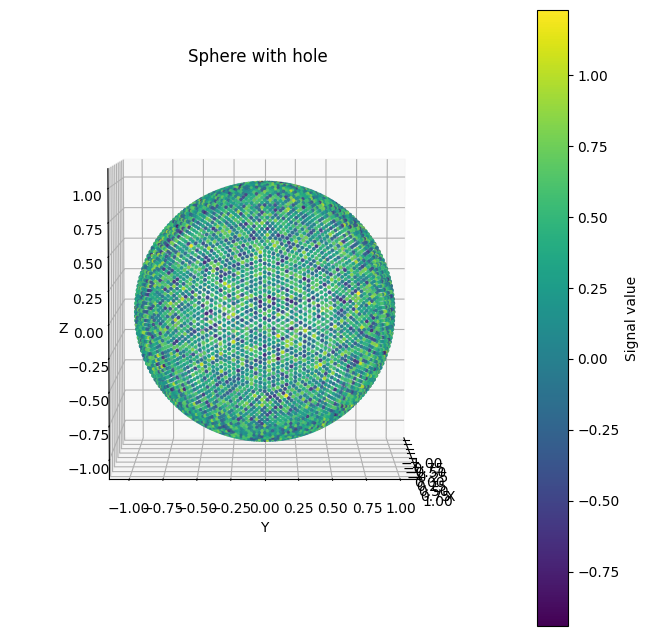

In [472]:
draw_graph(cartesian_pos=cartesian_pos, signal=out.detach().numpy(), edges=None)

In [433]:
out.min()

tensor(-9.2830, grad_fn=<MinBackward1>)

In [434]:
out.max()

tensor(9.7998, grad_fn=<MaxBackward1>)